
## Эксперименты с алгоритмом SAC в среде InvertedDoublePendulum

### **Цель:** Обучить агента с разными гиперпараметрами и проанализировать влияние на сходимость.

### **Среда:** `InvertedDoublePendulum-v4` (MuJoCo через Gymnasium)
### **Алгоритм:** Soft Actor-Critic (SAC) из Stable Baselines3
### **Метрики:** Среднее эпизодическое вознаграждение



In [ ]:
import gymnasium as gym
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import numpy as np
import os

import warnings
warnings.filterwarnings("ignore")

In [7]:
# Создаем папку для сохранения логов
log_dir = "./tmp/"
os.makedirs(log_dir, exist_ok=True)

In [8]:
# Этот колбэк будет сохранять награду после каждого эпизода
class RewardCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(RewardCallback, self).__init__(verbose)
        self.episode_rewards = []

    def _on_step(self):
        # Проверяем, завершился ли эпизод
        if self.locals.get('dones') and any(self.locals['dones']):
            # Берем последнюю награду из буфера мониторинга
            if len(self.model.ep_info_buffer) > 0:
                last_info = self.model.ep_info_buffer[-1]
                episode_reward = last_info['r']
                self.episode_rewards.append(episode_reward)
        return True

In [ ]:
# Функция для проведения одного эксперимента
def run_experiment(exp_name, learning_rate, batch_size, gamma, total_timesteps=100000):
    print(f"Запуск: {exp_name}")

    # Создаем окружение с оберткой для мониторинга
    env = Monitor(gym.make("HalfCheetah-v4"))

    # Инициализируем модель SAC с нужными гиперпараметрами
    model = SAC(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,
        batch_size=batch_size,
        gamma=gamma,
        verbose=0,
        device='cuda', # Использовать GPU, если доступен, иначе автоматически будет CPU
        tensorboard_log=log_dir
    )

    # Создаем колбэк для сбора наград
    reward_callback = RewardCallback()

    # Запускаем обучение
    model.learn(
        total_timesteps=total_timesteps,
        callback=reward_callback,
        tb_log_name=exp_name,
        progress_bar=True # покажет красивый прогресс-бар
    )

    env.close()
    return reward_callback.episode_rewards

---

### Описание гиперпараметров и логика экспериментов

**1. `learning_rate` (Скорость обучения)**  
Определяет величину шага при обновлении весов нейронных сетей (политики и Q-функций). Слишком большое значение может привести к нестабильности и "перескокам" через оптимум, а слишком маленькое - к медленной сходимости.  
*В эксперименте:* повышение с `0.0003` до `0.001` проверяет гипотезу об ускорении обучения ценой возможной потери стабильности.

**2. `batch_size` (Размер батча)**  
Количество переходов (`state`, `action`, `reward`, `next_state`), извлекаемых из буфера воспроизведения для одного градиентного шага. Больший размер батча даёт более точную оценку градиента и стабилизирует обучение, но требует больше памяти и может замедлить частоту обновлений.  
*В эксперименте:* увеличение с `256` до `512` направлено на повышение плавности и стабильности кривой награды.

**3. `gamma` (Коэффициент дисконтирования)**  
Параметр в диапазоне (0; 1), определяющий "дальновидность" агента. Значения, близкие к 1, заставляют агента учитывать долгосрочные последствия действий; близкие к 0 делают его "жадным" и сфокусированным на немедленной награде.  
*В эксперименте:* значение `0.99` зафиксировано для всех запусков, так как в задачах управления с длинным горизонтом (HalfCheetah) стандартно используется высокая дальновидность.

---

### Матрица экспериментов

| Эксперимент | `learning_rate` | `batch_size` | `gamma` | Цель изменения |
| :--- | :---: | :---: | :---: | :--- |
| **1. Базовый** | 0.0003 | 256 | 0.99 | Получить эталонную кривую обучения. |
| **2. Ускорение** | **0.001** ↑ | 256 | 0.99 | Оценить влияние повышенной скорости обучения на скорость и стабильность сходимости. |
| **3. Стабильность** | 0.0003 | **512** ↑ | 0.99 | Проверить, приводит ли увеличение размера батча к более гладкому и надёжному росту награды. |


In [ ]:
# Запуск всех экспериментов и визуализация
total_timesteps = 200000

# Эксперимент 1: Базовый
rewards_1 = run_experiment("Exp1_Base", learning_rate=0.0003,
                           batch_size=256, gamma=0.99, total_timesteps=total_timesteps)
print(f"Базовый эксперимент завершен. Эпизодов: {len(rewards_1)}")

# Эксперимент 2: Увеличенная скорость обучения
rewards_2 = run_experiment("Exp2_LR", learning_rate=0.001,
                           batch_size=256, gamma=0.99, total_timesteps=total_timesteps)
print(f"Эксперимент с LR завершен. Эпизодов: {len(rewards_2)}")

# Эксперимент 3: Увеличенный размер батча
rewards_3 = run_experiment("Exp3_BS", learning_rate=0.0003,
                           batch_size=512, gamma=0.99, total_timesteps=total_timesteps)
print(f"Эксперимент с BS завершен. Эпизодов: {len(rewards_3)}")

Запуск: Exp1_Base

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200,000/200,000  [ 0:18:14 < 0:00:00 , 184 it/s ]

Базовый эксперимент завершен. Эпизодов: 199

Запуск: Exp2_LR

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200,000/200,000  [ 0:17:57 < 0:00:00 , 186 it/s ]

Эксперимент с LR завершен. Эпизодов: 199

Запуск: Exp3_BS

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200,000/200,000  [ 0:22:52 < 0:00:00 , 147 it/s ]

Эксперимент с BS завершен. Эпизодов: 199

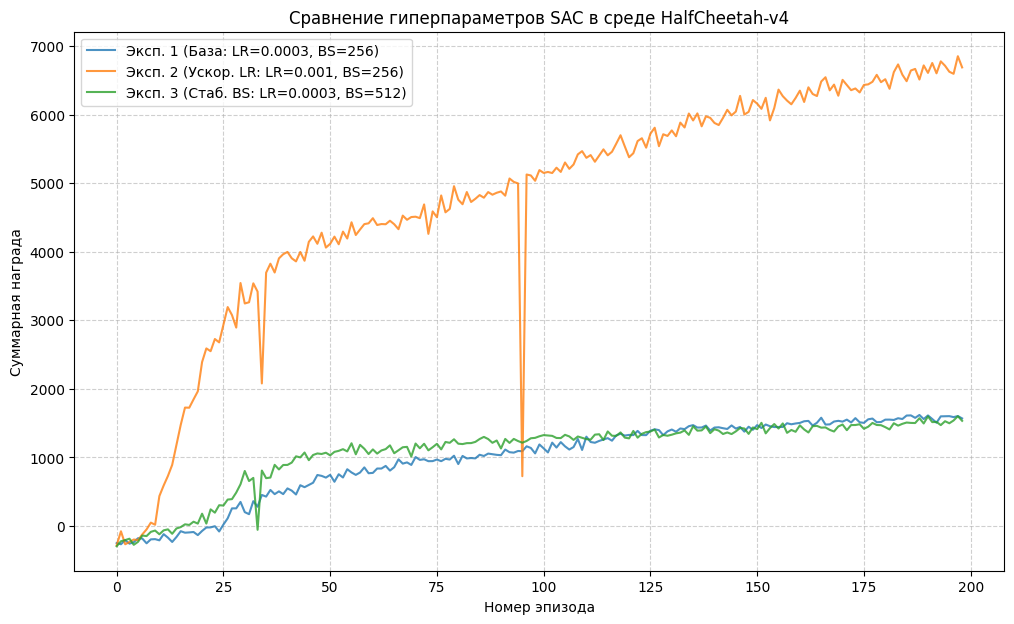

In [11]:
# Ячейка 5: Построение графика
plt.figure(figsize=(12, 7))

# Строим кривые обучения
plt.plot(rewards_1, label='Эксп. 1 (База: LR=0.0003, BS=256)', alpha=0.8)
plt.plot(rewards_2, label='Эксп. 2 (Ускор. LR: LR=0.001, BS=256)', alpha=0.8)
plt.plot(rewards_3, label='Эксп. 3 (Стаб. BS: LR=0.0003, BS=512)', alpha=0.8)

plt.xlabel('Номер эпизода')
plt.ylabel('Суммарная награда')
plt.title('Сравнение гиперпараметров SAC в среде HalfCheetah-v4')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Показываем график
plt.show()

---

### Результаты экспериментов


#### Матрица выводов

| Эксперимент | `learning_rate` | `batch_size` | `gamma` | Вывод |
| :--- | :---: | :---: | :---: | :--- |
| **1. Базовый** | 0.0003 | 256 | 0.99 | Низкая скорость, оптимум по награде не достигнут, допустимая дисперсия |
| **2. Ускорение** | **0.001** ↑ | 256 | 0.99 | Высокая скорость сходимости, кратное увеличение достигаемой награды, высокая дисперсия |
| **3. Стабильность** | 0.0003 | **512** ↑ | 0.99 | Низкая скорость, оптимум по награде не достигнут, но достигнуто преимущество по награде относительно базового подхода, низкая дисперсия |

#### Итоговый вывод:
Оптимальные параметры `learning_rate` = **0.001**, `batch_size` = 256, `gamma` = 0.99
